In [1]:
import sys
sys.path.insert(0, '/media/raid0/US_FiLMUNet')
import torch
from safetensors.torch import load_file
from nets.unet_attn import UNet2DAttn
from nets.segm_net import UNet2DFiLM


In [2]:
import sys
sys.path.insert(0, '/work/phd_ultrasounds/US_FiLMUNet')

import torch
from safetensors.torch import load_file
from nets.unet_attn import UNet2DAttn

CHECKPOINT = './loggings/1502cf4f7049/checkpoint-9200/model.safetensors'
# CHECKPOINT = './loggings/0c0d2b9760e3/checkpoint-9200/model.safetensors'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=10,
    size=16,
    depth=5,
    film_start=0,
    use_film=True,
    distill=False
)

state_dict = load_file(CHECKPOINT)
state_dict = {k: v for k, v in state_dict.items() if 'distill' not in k}
load_result = model.load_state_dict(state_dict, strict=False)
print(load_result)

model.eval()
model.to(DEVICE)
print(f"Model loaded on {DEVICE}")

<All keys matched successfully>
Model loaded on cuda


In [3]:
from torch.utils.data import DataLoader
from data_classes.datasets import USdatasetOmni
from utils.paths import DATA_DIR
from utils.utils import get_sft_transforms

BATCH_SIZE = 16

train_dataset = USdatasetOmni(
    base_dir=DATA_DIR,
    split='train',
    transforms=get_sft_transforms(train=False),
    out_size=512,
    data_type='segmentation',
    ccl_crop=False,
    keep_aspect_ratio=True,
    self_norm=False,
    id_dropout=0.0,
)

test_dataset = USdatasetOmni(
    base_dir=DATA_DIR,
    split='val',
    transforms=get_sft_transforms(train=False),
    out_size=512,
    data_type='segmentation',
    ccl_crop=False,
    keep_aspect_ratio=True,
    self_norm=False,
    id_dropout=0.0,
)

import random

random.shuffle(train_dataset.items)
train_dataset.items = train_dataset.items[:100]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
# test_dataset.items = test_dataset.items[:2]
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

Train: 100 images | Test: 1404 images


In [4]:
from tqdm import tqdm
import matplotlib.pyplot as plt


def collect_modulations(model, loader, device):
    """
    Run inference and collect compact FiLM summaries for each image.

    Returns:
        gamma_maxes:   (N, L, Cmax) cpu tensor
        beta_maxes:    (N, L, Cmax) cpu tensor
        attn_out_maps: (N, L, emb_dim) cpu tensor  -- raw attn context vector per layer
        organ_ids:     (N,) cpu tensor
    """
    if not getattr(model, 'use_attn', False):
        raise ValueError('This helper expects an attention-modulated model.')

    gamma_maxes, beta_maxes, attn_out_maps, organ_ids = [], [], [], []
    model.eval()
    layer_configs = model._build_layer_configs()

    with torch.no_grad():
        for batch in tqdm(loader):
            pixel_values = batch['pixel_values'].to(device)
            batch_organ_id = batch['organ_id'].long().to(device)

            _, _, compact_modulations = model.shared_attn.compute_all_modulations(
                pixel_values,
                batch_organ_id,
                layer_configs,
                return_compact=True,
            )

            # compact_modulations[layer_id] = (gamma_max, beta_max, attn_out)
            batch_gamma_max = torch.stack(
                [compact_modulations[layer_id][0] for layer_id, _ in layer_configs],
                dim=1,
            )
            batch_beta_max = torch.stack(
                [compact_modulations[layer_id][1] for layer_id, _ in layer_configs],
                dim=1,
            )
            batch_attn_out = torch.stack(
                [compact_modulations[layer_id][2] for layer_id, _ in layer_configs],
                dim=1,
            )

            gamma_maxes.append(batch_gamma_max.cpu())
            beta_maxes.append(batch_beta_max.cpu())
            attn_out_maps.append(batch_attn_out.cpu())
            organ_ids.append(batch_organ_id.cpu())

    gamma_maxes = torch.cat(gamma_maxes, dim=0)
    beta_maxes = torch.cat(beta_maxes, dim=0)
    attn_out_maps = torch.cat(attn_out_maps, dim=0)
    organ_ids = torch.cat(organ_ids, dim=0)
    return gamma_maxes, beta_maxes, attn_out_maps, organ_ids


def compact_for_heatmap(modulations, reduction='mean'):
    """Collapse the image axis to get a (layers, compact_channels) heatmap."""
    if reduction == 'mean':
        return modulations.mean(dim=0)
    if reduction == 'abs_mean':
        return modulations.abs().mean(dim=0)
    raise ValueError(f'Unsupported reduction: {reduction}')


gamma_max_test, beta_max_test, attn_out_test, organ_ids_test = collect_modulations(model, train_loader, DEVICE)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  4.61it/s]


In [5]:
i = 4
gamma_heatmap = torch.nn.functional.max_pool1d(gamma_max_test[i], kernel_size=4)
beta_heatmap = torch.nn.functional.max_pool1d(beta_max_test[i], kernel_size=4)
gamma_heatmap = torch.nn.functional.normalize(gamma_heatmap, p=2, dim= 0)
beta_heatmap = torch.nn.functional.normalize(beta_heatmap, p=2,  dim= 0)

organ_ids_test[i]

tensor(1)

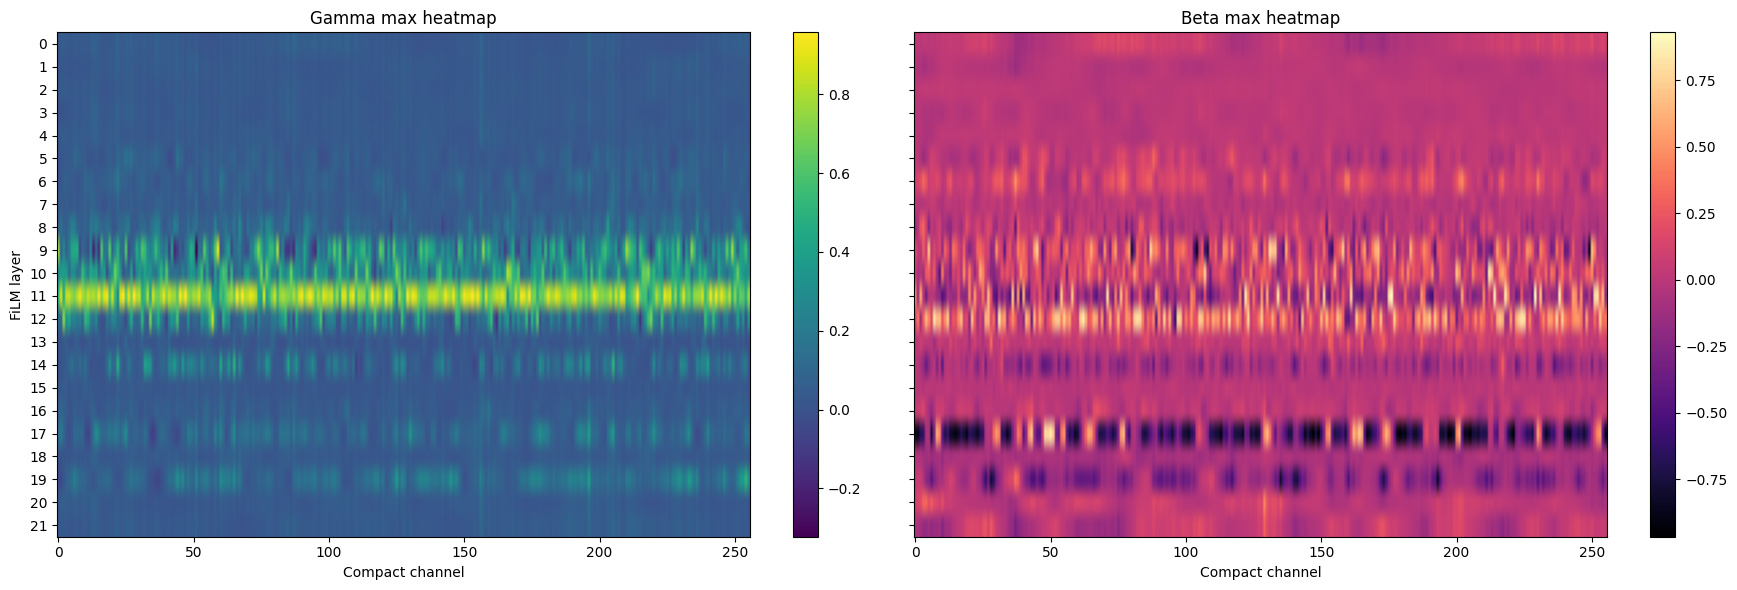

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

im0 = axes[0].imshow(gamma_heatmap.numpy(), aspect='auto', cmap='viridis')
axes[0].set_title('Gamma max heatmap')
axes[0].set_xlabel('Compact channel')
axes[0].set_ylabel('FiLM layer')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(beta_heatmap.numpy(), aspect='auto', cmap='magma')
axes[1].set_title('Beta max heatmap')
axes[1].set_xlabel('Compact channel')
fig.colorbar(im1, ax=axes[1])

layer_ticks = list(range(gamma_heatmap.shape[0]))
for ax in axes:
    ax.set_yticks(layer_ticks)

plt.tight_layout()
plt.show()

In [7]:
j = 58
gamma_heatmap = torch.nn.functional.max_pool1d(gamma_max_test[j], kernel_size=16)
beta_heatmap = torch.nn.functional.max_pool1d(beta_max_test[j], kernel_size=16)
gamma_heatmap = torch.nn.functional.normalize(gamma_heatmap, p=2, dim= 0)
beta_heatmap = torch.nn.functional.normalize(beta_heatmap, p=2,  dim= 0)

organ_ids_test[j]

tensor(1)

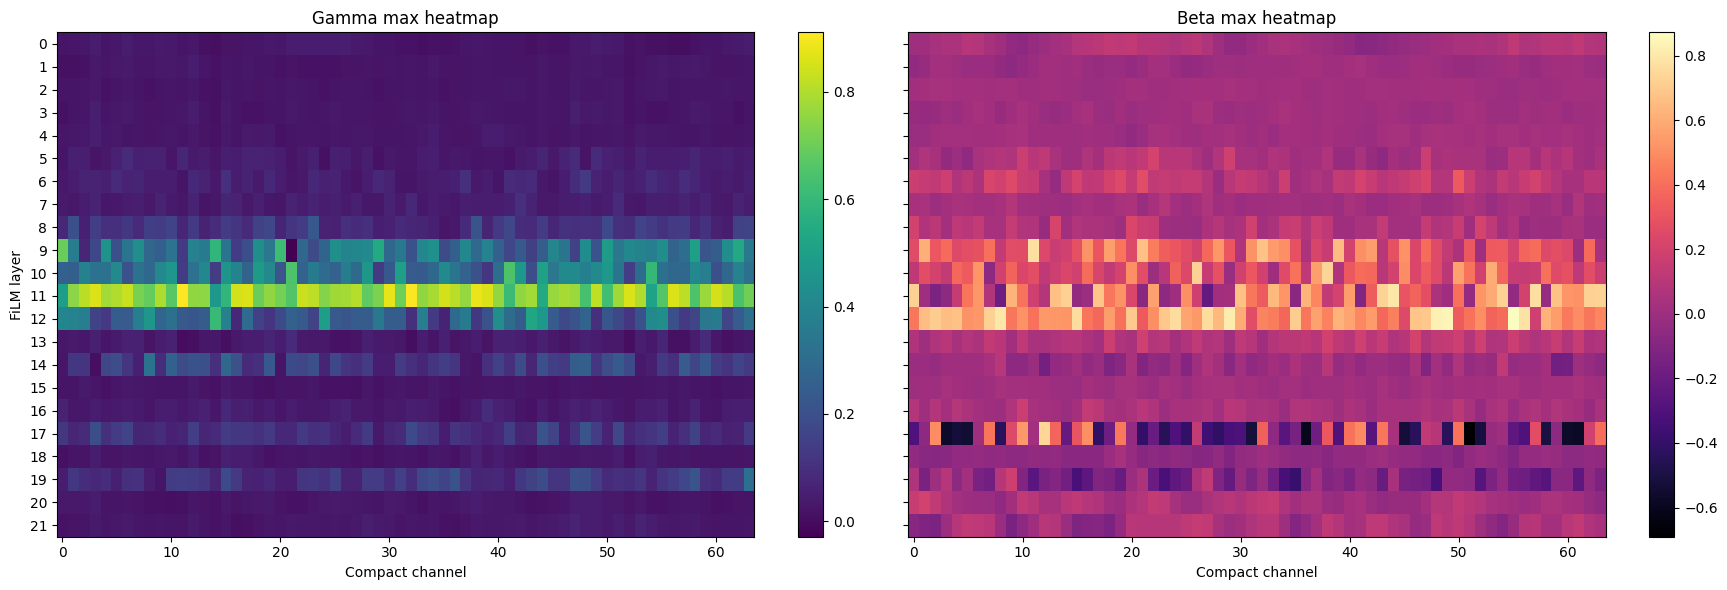

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

im0 = axes[0].imshow(gamma_heatmap.numpy(), aspect='auto', cmap='viridis')
axes[0].set_title('Gamma max heatmap')
axes[0].set_xlabel('Compact channel')
axes[0].set_ylabel('FiLM layer')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(beta_heatmap.numpy(), aspect='auto', cmap='magma')
axes[1].set_title('Beta max heatmap')
axes[1].set_xlabel('Compact channel')
fig.colorbar(im1, ax=axes[1])

layer_ticks = list(range(gamma_heatmap.shape[0]))
for ax in axes:
    ax.set_yticks(layer_ticks)

plt.tight_layout()
plt.show()

In [9]:
# ── Full training set collection ──────────────────────────────────────────────
# Use the entire train split (no 100-sample cap) so we have enough examples per organ.
from torch.utils.data import DataLoader
from data_classes.datasets import USdatasetOmni
from utils.paths import DATA_DIR
from utils.utils import get_sft_transforms

full_train_dataset = USdatasetOmni(
    base_dir=DATA_DIR,
    split='train',
    transforms=get_sft_transforms(train=False),
    out_size=512,
    data_type='segmentation',
    ccl_crop=False,
    keep_aspect_ratio=True,
    self_norm=False,
    id_dropout=0.0,
)
full_train_loader = DataLoader(
    full_train_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True
)
print(f"Full train: {len(full_train_dataset)} images")

gamma_all, beta_all, attn_all, organ_ids_all = collect_modulations(model, full_train_loader, DEVICE)
print(f"gamma={gamma_all.shape}  beta={beta_all.shape}  attn={attn_all.shape}")
print(f"Unique organ ids: {organ_ids_all.unique().tolist()}")


Full train: 5219 images


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [00:33<00:00, 19.39it/s]


gamma=torch.Size([5219, 22, 1024])  beta=torch.Size([5219, 22, 1024])  attn=torch.Size([5219, 22, 64])
Unique organ ids: [1, 2, 3, 4, 5, 7]


In [10]:
# ── Save per-organ clusters (gamma / beta / attn_out heatmaps) ────────────────
import os
import torch.nn.functional as F

POOL_K = 32           # reduce 768-dim → 48 bins for display
SAMPLES_PER_ORGAN = 16
OUT_DIR = './modulation_clusters_only_film'

os.makedirs(OUT_DIR, exist_ok=True)

unique_organs = sorted(organ_ids_all.unique().tolist())

for organ_id in unique_organs:
    organ_id = int(organ_id)
    indices = (organ_ids_all == organ_id).nonzero(as_tuple=True)[0][:SAMPLES_PER_ORGAN]
    n = len(indices)

    organ_dir = os.path.join(OUT_DIR, f'organ_{organ_id}')
    os.makedirs(organ_dir, exist_ok=True)

    # ── individual sample figures ──────────────────────────────────────────────
    for rank, idx in enumerate(indices.tolist()):
        def _prep(t):
            t = F.max_pool1d(t, kernel_size=POOL_K)
            return F.normalize(t, p=2, dim=0).numpy()

        g = _prep(gamma_all[idx])   # (L, C/POOL_K)
        b = _prep(beta_all[idx])
        a = _prep(attn_all[idx])

        fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

        im0 = axes[0].imshow(g, aspect='auto', cmap='viridis')
        axes[0].set_title(f'Gamma  [organ {organ_id}, sample {rank}]')
        axes[0].set_xlabel('Pooled channel')
        axes[0].set_ylabel('FiLM layer')
        fig.colorbar(im0, ax=axes[0])

        im1 = axes[1].imshow(b, aspect='auto', cmap='magma')
        axes[1].set_title(f'Beta  [organ {organ_id}, sample {rank}]')
        axes[1].set_xlabel('Pooled channel')
        fig.colorbar(im1, ax=axes[1])

        im2 = axes[2].imshow(a, aspect='auto', cmap='plasma')
        axes[2].set_title(f'Attn-out  [organ {organ_id}, sample {rank}]')
        axes[2].set_xlabel('Pooled channel')
        fig.colorbar(im2, ax=axes[2])

        layer_ticks = list(range(g.shape[0]))
        for ax in axes:
            ax.set_yticks(layer_ticks)

        plt.tight_layout()
        fig.savefig(os.path.join(organ_dir, f'sample_{rank:02d}.png'), dpi=80, bbox_inches='tight')
        plt.close(fig)

    # ── mean summary figure ────────────────────────────────────────────────────
    def _mean_prep(t_all):
        t = F.max_pool1d(t_all, kernel_size=POOL_K).mean(dim=0)
        t = F.normalize(t, p=2, dim=0)
        return t.numpy()                        # (L, C/POOL_K)

    gm = _mean_prep(gamma_all[organ_ids_all==organ_id])
    bm = _mean_prep(beta_all[organ_ids_all==organ_id])
    am = _mean_prep(attn_all[organ_ids_all==organ_id])


    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    fig.suptitle(f'Organ {organ_id} — mean over {n} samples', fontsize=13)

    im0 = axes[0].imshow(gm, aspect='auto', cmap='viridis')
    axes[0].set_title('Gamma mean')
    axes[0].set_xlabel('Pooled channel')
    axes[0].set_ylabel('FiLM layer')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(bm, aspect='auto', cmap='magma')
    axes[1].set_title('Beta mean')
    axes[1].set_xlabel('Pooled channel')
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(am, aspect='auto', cmap='plasma')
    axes[2].set_title('Attn-out mean')
    axes[2].set_xlabel('Pooled channel')
    fig.colorbar(im2, ax=axes[2])

    layer_ticks = list(range(gm.shape[0]))
    for ax in axes:
        ax.set_yticks(layer_ticks)

    plt.tight_layout()
    fig.savefig(os.path.join(organ_dir, 'mean.png'), dpi=80, bbox_inches='tight')
    plt.close(fig)

    print(f'Organ {organ_id}: {n} samples saved to {organ_dir}/')

print(f'\nDone. Clusters saved under {OUT_DIR}/')


Organ 1: 16 samples saved to ./modulation_clusters_only_film/organ_1/
Organ 2: 16 samples saved to ./modulation_clusters_only_film/organ_2/
Organ 3: 16 samples saved to ./modulation_clusters_only_film/organ_3/
Organ 4: 16 samples saved to ./modulation_clusters_only_film/organ_4/
Organ 5: 16 samples saved to ./modulation_clusters_only_film/organ_5/
Organ 7: 16 samples saved to ./modulation_clusters_only_film/organ_7/

Done. Clusters saved under ./modulation_clusters_only_film/


In [11]:
# ── Collect modulations from the test (val) split ─────────────────────────────
gamma_test_all, beta_test_all, attn_test_all, organ_ids_test_all = collect_modulations(model, test_loader, DEVICE)
print(f"gamma={gamma_test_all.shape}  beta={beta_test_all.shape}  attn={attn_test_all.shape}")
print(f"Unique organ ids: {organ_ids_test_all.unique().tolist()}")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:08<00:00,  9.98it/s]

gamma=torch.Size([1404, 22, 1024])  beta=torch.Size([1404, 22, 1024])  attn=torch.Size([1404, 22, 64])
Unique organ ids: [1, 2, 3, 4, 5, 7]


In [12]:
# ── Save per-organ clusters for test split ────────────────────────────────────
OUT_DIR_TEST = './modulation_clusters_only_film_test'
os.makedirs(OUT_DIR_TEST, exist_ok=True)

unique_organs_test = sorted(organ_ids_test_all.unique().tolist())

for organ_id in unique_organs_test:
    organ_id = int(organ_id)
    indices = (organ_ids_test_all == organ_id).nonzero(as_tuple=True)[0][:SAMPLES_PER_ORGAN]
    n = len(indices)

    organ_dir = os.path.join(OUT_DIR_TEST, f'organ_{organ_id}')
    os.makedirs(organ_dir, exist_ok=True)

    # ── individual sample figures ──────────────────────────────────────────────
    for rank, idx in enumerate(indices.tolist()):
        def _prep(t):
            t = F.max_pool1d(t, kernel_size=POOL_K)
            return F.normalize(t, p=2, dim=0).numpy()

        g = _prep(gamma_test_all[idx])
        b = _prep(beta_test_all[idx])
        a = _prep(attn_test_all[idx])

        fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

        im0 = axes[0].imshow(g, aspect='auto', cmap='viridis')
        axes[0].set_title(f'Gamma  [organ {organ_id}, sample {rank}]')
        axes[0].set_xlabel('Pooled channel')
        axes[0].set_ylabel('FiLM layer')
        fig.colorbar(im0, ax=axes[0])

        im1 = axes[1].imshow(b, aspect='auto', cmap='magma')
        axes[1].set_title(f'Beta  [organ {organ_id}, sample {rank}]')
        axes[1].set_xlabel('Pooled channel')
        fig.colorbar(im1, ax=axes[1])

        im2 = axes[2].imshow(a, aspect='auto', cmap='plasma')
        axes[2].set_title(f'Attn-out  [organ {organ_id}, sample {rank}]')
        axes[2].set_xlabel('Pooled channel')
        fig.colorbar(im2, ax=axes[2])

        layer_ticks = list(range(g.shape[0]))
        for ax in axes:
            ax.set_yticks(layer_ticks)

        plt.tight_layout()
        fig.savefig(os.path.join(organ_dir, f'sample_{rank:02d}.png'), dpi=80, bbox_inches='tight')
        plt.close(fig)

    # ── mean summary figure ────────────────────────────────────────────────────
    def _mean_prep(t_all):
        t = F.max_pool1d(t_all, kernel_size=POOL_K).mean(dim=0)
        t = F.normalize(t, p=2, dim=0)
        return t.numpy()

    gm = _mean_prep(gamma_test_all[organ_ids_test_all==organ_id])
    bm = _mean_prep(beta_test_all[organ_ids_test_all==organ_id])
    am = _mean_prep(attn_test_all[organ_ids_test_all==organ_id])

    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    fig.suptitle(f'Organ {organ_id} — mean over {n} samples (test)', fontsize=13)

    im0 = axes[0].imshow(gm, aspect='auto', cmap='viridis')
    axes[0].set_title('Gamma mean')
    axes[0].set_xlabel('Pooled channel')
    axes[0].set_ylabel('FiLM layer')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(bm, aspect='auto', cmap='magma')
    axes[1].set_title('Beta mean')
    axes[1].set_xlabel('Pooled channel')
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(am, aspect='auto', cmap='plasma')
    axes[2].set_title('Attn-out mean')
    axes[2].set_xlabel('Pooled channel')
    fig.colorbar(im2, ax=axes[2])

    layer_ticks = list(range(gm.shape[0]))
    for ax in axes:
        ax.set_yticks(layer_ticks)

    plt.tight_layout()
    fig.savefig(os.path.join(organ_dir, 'mean.png'), dpi=80, bbox_inches='tight')
    plt.close(fig)

    print(f'Organ {organ_id}: {n} samples saved to {organ_dir}/')

print(f'\nDone. Test clusters saved under {OUT_DIR_TEST}/')


Organ 1: 16 samples saved to ./modulation_clusters_only_film_test/organ_1/
Organ 2: 16 samples saved to ./modulation_clusters_only_film_test/organ_2/
Organ 3: 16 samples saved to ./modulation_clusters_only_film_test/organ_3/
Organ 4: 16 samples saved to ./modulation_clusters_only_film_test/organ_4/
Organ 5: 16 samples saved to ./modulation_clusters_only_film_test/organ_5/
Organ 7: 16 samples saved to ./modulation_clusters_only_film_test/organ_7/

Done. Test clusters saved under ./modulation_clusters_only_film_test/


## Organ embedding analysis — UMAP + cosine similarity

In [13]:
# ── UMAP / t-SNE of per-image modulation vectors ─────────────────────────────
# Feature: mean-pool layers, concat gamma + beta → (N, 2048)
# Train and test are embedded in the same space for direct comparison.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

MAX_PER_SPLIT = 100   # cap to keep UMAP fast; set higher if you want more detail
rng = np.random.default_rng(42)

def subsample(feats, ids, max_n):
    if len(feats) <= max_n:
        return feats, ids
    idx = rng.choice(len(feats), max_n, replace=False)
    return feats[idx], ids[idx]

# Ids present in the training split are the "trained" ids
TRAINED_IDS = set(int(x) for x in organ_ids_all.unique().tolist())

feats_train = torch.cat([gamma_all.mean(dim=1),      beta_all.mean(dim=1)],      dim=1).numpy()
feats_test  = torch.cat([gamma_test_all.mean(dim=1), beta_test_all.mean(dim=1)], dim=1).numpy()

feats_train_s, ids_train_s = subsample(feats_train, organ_ids_all.numpy(),      MAX_PER_SPLIT)
feats_test_s,  ids_test_s  = subsample(feats_test,  organ_ids_test_all.numpy(), MAX_PER_SPLIT)

feats_combined = np.concatenate([feats_train_s, feats_test_s], axis=0)
ids_combined   = np.concatenate([ids_train_s, ids_test_s])
split_combined = np.array(['train'] * len(feats_train_s) + ['test'] * len(feats_test_s))

print(f'Using {len(feats_train_s)} train + {len(feats_test_s)} test samples for embedding.')

# PCA → 50 dims to denoise before UMAP / t-SNE
feats_scaled = StandardScaler().fit_transform(feats_combined)
feats_pca    = PCA(n_components=50, random_state=42).fit_transform(feats_scaled)

try:
    import umap
    embedding = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(feats_pca)
    method = 'UMAP'
except ImportError:
    from sklearn.manifold import TSNE
    embedding = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feats_pca)
    method = 't-SNE'

print(f'{method} embedding: {embedding.shape}')

# ── Plot ──────────────────────────────────────────────────────────────────────
unique_ids = sorted(set(ids_combined.tolist()))
cmap       = plt.get_cmap('tab10', len(unique_ids))
id_to_col  = {oid: cmap(i) for i, oid in enumerate(unique_ids)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
titles = ['train split', 'test split']
splits = ['train', 'test']

for ax, split, title in zip(axes, splits, titles):
    mask_split = split_combined == split
    for oid in unique_ids:
        mask = mask_split & (ids_combined == oid)
        if not mask.any():
            continue
        is_ood  = int(oid) not in TRAINED_IDS
        marker  = 'X' if is_ood else 'o'
        ec      = 'k' if is_ood else 'none'
        label   = f'id {int(oid)}' + (' (OOD)' if is_ood else '')
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=[id_to_col[oid]], marker=marker, s=50, alpha=0.75,
            edgecolors=ec, linewidths=0.8, label=label,
        )
    ax.set_title(f'{method} — {title}')
    ax.set_xlabel(f'{method} 1')
    ax.set_ylabel(f'{method} 2')
    ax.legend(loc='best', framealpha=0.8, fontsize=8)

fig.suptitle('Per-image modulation embeddings (γ+β mean-pooled, trained vs OOD)', fontsize=13)
plt.tight_layout()
plt.show()


In [14]:
# ── Intra-class cohesion vs inter-class separation ───────────────────────────
# cohesion  = mean pairwise cosine sim within an organ's own samples
# separation = mean cosine sim between that organ's centroid and every other organ's centroid
# Trained ids should be tight and distinct; OOD id 7 typically shows low cohesion.
import torch.nn.functional as F

def cosine_stats(feats_t, ids_t):
    unique  = sorted(int(x) for x in ids_t.unique().tolist())
    normed  = F.normalize(feats_t.float(), dim=1)
    centroids = {oid: normed[ids_t == oid].mean(dim=0) for oid in unique}

    result = {}
    for oid in unique:
        vecs = normed[ids_t == oid]          # (n, D)
        n    = vecs.shape[0]

        if n > 1:
            sim_mat  = vecs @ vecs.T         # (n, n)
            cohesion = (sim_mat.sum() - n) / (n * (n - 1))
        else:
            cohesion = torch.tensor(1.0)

        other_c = torch.stack([c for k, c in centroids.items() if k != oid])
        separation = (centroids[oid].unsqueeze(0) @ other_c.T).mean()

        result[oid] = (cohesion.item(), separation.item())
    return result


feats_train_t = torch.cat([gamma_all.mean(dim=1),      beta_all.mean(dim=1)],      dim=1)
feats_test_t  = torch.cat([gamma_test_all.mean(dim=1), beta_test_all.mean(dim=1)], dim=1)

stats_train = cosine_stats(feats_train_t, organ_ids_all)
stats_test  = cosine_stats(feats_test_t,  organ_ids_test_all)


def plot_cosine_stats(stats, title, trained_ids):
    organs      = sorted(stats.keys())
    cohesions   = [stats[o][0] for o in organs]
    separations = [stats[o][1] for o in organs]
    x     = np.arange(len(organs))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width / 2, cohesions,   width, label='Intra-class cohesion',   color='steelblue')
    bars2 = ax.bar(x + width / 2, separations, width, label='Inter-class separation', color='tomato')

    ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=7)
    ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=7)

    xlabels = [f'id {o}' + ('\n(OOD)' if o not in trained_ids else '') for o in organs]
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Mean cosine similarity')
    ax.set_title(title)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_cosine_stats(stats_train, 'Cosine similarity stats — train split', TRAINED_IDS)
plot_cosine_stats(stats_test,  'Cosine similarity stats — test split',  TRAINED_IDS)


In [15]:
# ── Magnitude curves across depth ────────────────────────────────────────────
# L2 norm of γ, β, attn_out at each layer, per organ, mean ± std band.
# No normalization — magnitude is the key OOD signal.
# Uses the test split (contains all organs including untrained id 7).
import numpy as np
import matplotlib.pyplot as plt

layers      = np.arange(gamma_test_all.shape[1])
test_unique = sorted(int(x) for x in organ_ids_test_all.unique().tolist())
cmap_mag    = plt.get_cmap('tab10', len(test_unique))
id_to_col_mag = {oid: cmap_mag(i) for i, oid in enumerate(test_unique)}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, ylabel in zip(
    axes,
    [gamma_test_all, beta_test_all, attn_test_all],
    ['‖γ‖', '‖β‖', '‖attn_out‖'],
):
    norms = data.norm(dim=2)  # (N, 22)

    for oid in test_unique:
        mask        = organ_ids_test_all == oid
        organ_norms = norms[mask].numpy()   # (n, 22)
        mean        = organ_norms.mean(axis=0)
        std         = organ_norms.std(axis=0)
        is_ood      = oid not in TRAINED_IDS
        color       = id_to_col_mag[oid]
        label       = f'id {oid}' + (' (OOD)' if is_ood else '')

        ax.plot(layers, mean, label=label, color=color,
                linestyle='--' if is_ood else '-', linewidth=2)
        ax.fill_between(layers, mean - std, mean + std, alpha=0.12, color=color)

    ax.set_title(ylabel)
    ax.set_xlabel('Layer index')
    ax.set_ylabel(ylabel)
    ax.set_xticks(layers)
    ax.legend(fontsize=8, framealpha=0.8)

fig.suptitle('Layer-wise modulation magnitude — test split (trained vs OOD)', fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
# ── Difference heatmaps: organ_mean − trained_mean ───────────────────────────
# Subtracting the global trained-class mean removes shared structure and makes
# each organ's unique signature (or lack thereof) pop out.
# Id 7 showing ≈0 everywhere → model collapses it onto the average trained response.
# Id 7 showing noisy speckle  → model has no consistent representation for it.
import torch.nn.functional as F
import matplotlib.pyplot as plt

POOL_K_DIFF = 16  # pool 1024 → 64 bins for display

def diff_heatmaps(data, ids, trained_ids, pool_k):
    """Returns dict: organ_id → (L, C/pool_k) diff array."""
    trained_mask = torch.tensor([int(x) in trained_ids for x in ids])
    trained_mean = data[trained_mask].float().mean(dim=0)  # (L, C)

    result = {}
    for oid in sorted(int(x) for x in ids.unique().tolist()):
        mask       = ids == oid
        organ_mean = data[mask].float().mean(dim=0)        # (L, C)
        diff       = organ_mean - trained_mean             # (L, C)
        diff_pooled = F.max_pool1d(diff, kernel_size=pool_k)  # (L, C/pool_k)
        result[oid] = diff_pooled.numpy()
    return result

gamma_diffs = diff_heatmaps(gamma_test_all, organ_ids_test_all, TRAINED_IDS, POOL_K_DIFF)
beta_diffs  = diff_heatmaps(beta_test_all,  organ_ids_test_all, TRAINED_IDS, POOL_K_DIFF)

organs_diff = sorted(gamma_diffs.keys())
n_organs    = len(organs_diff)

fig, axes = plt.subplots(n_organs, 2, figsize=(16, 4 * n_organs), sharey='row')
fig.suptitle('Δγ and Δβ per organ  (organ mean − trained mean)', fontsize=13)

for row, oid in enumerate(organs_diff):
    is_ood = oid not in TRAINED_IDS
    suffix = ' (OOD)' if is_ood else ''

    g_diff = gamma_diffs[oid]
    b_diff = beta_diffs[oid]
    vmax   = max(abs(g_diff).max(), abs(b_diff).max())

    ax0, ax1 = axes[row, 0], axes[row, 1]

    im0 = ax0.imshow(g_diff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax0.set_title(f'Δγ  — organ {oid}{suffix}')
    ax0.set_xlabel('Pooled channel')
    ax0.set_ylabel('Layer')
    ax0.set_yticks(range(g_diff.shape[0]))
    fig.colorbar(im0, ax=ax0, fraction=0.03)

    im1 = ax1.imshow(b_diff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax1.set_title(f'Δβ  — organ {oid}{suffix}')
    ax1.set_xlabel('Pooled channel')
    ax1.set_yticks(range(b_diff.shape[0]))
    fig.colorbar(im1, ax=ax1, fraction=0.03)

plt.tight_layout()
plt.show()


## Activation analysis — post-FiLM feature maps
The same UMAP / cohesion / magnitude views, but on the actual modulated activations inside the U-Net rather than the FiLM coefficients themselves. The coefficients tell us what the conditioning network produces; the activations tell us what the network actually does with them.

In [17]:
# ── Collect post-FiLM activations via forward hooks ───────────────────────────
# For each FiLMLayer instance, capture (B, C, H, W) output and reduce to (B, C)
# via spatial mean. Channel counts vary per layer, so we keep a list of
# per-layer tensors: layer_acts[l] has shape (N, C_l).
from nets.unet_attn import FiLMLayer
from tqdm import tqdm

def collect_activations(model, loader, device):
    film_layers = [m for m in model.modules() if isinstance(m, FiLMLayer)]
    n_layers    = len(film_layers)
    layer_bufs  = [[] for _ in range(n_layers)]
    batch_slot  = [None] * n_layers

    def make_hook(idx):
        def hook(_module, _input, output):
            # output: (B, C, H, W) → (B, C)
            batch_slot[idx] = output.detach().mean(dim=(2, 3)).cpu()
        return hook

    hooks = [fl.register_forward_hook(make_hook(i)) for i, fl in enumerate(film_layers)]

    ids_list = []
    try:
        model.eval()
        with torch.no_grad():
            for batch in tqdm(loader):
                for i in range(n_layers):
                    batch_slot[i] = None

                pixel_values = batch['pixel_values'].to(device)
                organ_id     = batch['organ_id'].long().to(device)

                _ = model(pixel_values=pixel_values, organ_id=organ_id)

                for i in range(n_layers):
                    if batch_slot[i] is None:
                        raise RuntimeError(f'FiLM layer {i} never fired.')
                    layer_bufs[i].append(batch_slot[i])

                ids_list.append(organ_id.cpu())
    finally:
        for h in hooks:
            h.remove()

    layer_acts = [torch.cat(buf, dim=0) for buf in layer_bufs]
    ids        = torch.cat(ids_list, dim=0)
    return layer_acts, ids


acts_train, acts_train_ids = collect_activations(model, full_train_loader, DEVICE)
acts_test,  acts_test_ids  = collect_activations(model, test_loader,       DEVICE)

print(f'Train: {acts_train[0].shape[0]} images × {len(acts_train)} layers '
      f'(channels per layer: {[a.shape[1] for a in acts_train]})')
print(f'Test:  {acts_test[0].shape[0]}  images × {len(acts_test)} layers')


In [18]:
# ── UMAP / t-SNE on activation feature vectors ───────────────────────────────
# Per-image feature: concatenate spatial-mean activations across all FiLM layers.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

MAX_PER_SPLIT_ACT = 40

feats_train_act = torch.cat(acts_train, dim=1).numpy()  # (N_train, sum_C)
feats_test_act  = torch.cat(acts_test,  dim=1).numpy()  # (N_test,  sum_C)

print(f'Activation feature dim: {feats_train_act.shape[1]}')

feats_train_act_s, ids_train_act_s = subsample(feats_train_act, acts_train_ids.numpy(), MAX_PER_SPLIT_ACT)
feats_test_act_s,  ids_test_act_s  = subsample(feats_test_act,  acts_test_ids.numpy(),  MAX_PER_SPLIT_ACT)

feats_act_combined = np.concatenate([feats_train_act_s, feats_test_act_s], axis=0)
ids_act_combined   = np.concatenate([ids_train_act_s, ids_test_act_s])
split_act_combined = np.array(['train'] * len(feats_train_act_s) + ['test'] * len(feats_test_act_s))

feats_act_scaled = StandardScaler().fit_transform(feats_act_combined)
feats_act_pca    = PCA(n_components=50, random_state=42).fit_transform(feats_act_scaled)

try:
    import umap
    emb_act = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(feats_act_pca)
    method_act = 'UMAP'
except ImportError:
    from sklearn.manifold import TSNE
    emb_act = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feats_act_pca)
    method_act = 't-SNE'

print(f'{method_act} embedding: {emb_act.shape}')

# ── Plot ──────────────────────────────────────────────────────────────────────
unique_ids_act = sorted(set(ids_act_combined.tolist()))
cmap_act       = plt.get_cmap('tab10', len(unique_ids_act))
id_to_col_act  = {oid: cmap_act(i) for i, oid in enumerate(unique_ids_act)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

for ax, split, title in zip(axes, ['train', 'test'], ['train split', 'test split']):
    mask_split = split_act_combined == split
    for oid in unique_ids_act:
        mask = mask_split & (ids_act_combined == oid)
        if not mask.any():
            continue
        is_ood  = int(oid) not in TRAINED_IDS
        marker  = 'X' if is_ood else 'o'
        ec      = 'k' if is_ood else 'none'
        label   = f'id {int(oid)}' + (' (OOD)' if is_ood else '')
        ax.scatter(
            emb_act[mask, 0], emb_act[mask, 1],
            c=[id_to_col_act[oid]], marker=marker, s=50, alpha=0.75,
            edgecolors=ec, linewidths=0.8, label=label,
        )
    ax.set_title(f'{method_act} — {title}')
    ax.set_xlabel(f'{method_act} 1')
    ax.set_ylabel(f'{method_act} 2')
    ax.legend(loc='best', framealpha=0.8, fontsize=8)

fig.suptitle('Post-FiLM activation embeddings (spatial-mean concat across layers)', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── Cohesion / separation on activation feature vectors ─────────────────────
feats_train_act_t = torch.cat(acts_train, dim=1)  # (N_train, sum_C)
feats_test_act_t  = torch.cat(acts_test,  dim=1)

stats_train_act = cosine_stats(feats_train_act_t, acts_train_ids)
stats_test_act  = cosine_stats(feats_test_act_t,  acts_test_ids)

plot_cosine_stats(stats_train_act, 'Activation cosine stats — train split', TRAINED_IDS)
plot_cosine_stats(stats_test_act,  'Activation cosine stats — test split',  TRAINED_IDS)


In [ ]:
# ── Activation magnitude curves across depth ─────────────────────────────────
# Per-layer L2 norm of the spatially-averaged activation, per organ, mean ± std.
# A trained organ should produce confident, structured activations; an OOD id
# typically deviates in magnitude and/or variance.
import numpy as np
import matplotlib.pyplot as plt

n_layers_act  = len(acts_test)
layers_act    = np.arange(n_layers_act)
test_unique_a = sorted(int(x) for x in acts_test_ids.unique().tolist())
cmap_actmag   = plt.get_cmap('tab10', len(test_unique_a))
id_to_col_am  = {oid: cmap_actmag(i) for i, oid in enumerate(test_unique_a)}

# Precompute per-layer norms: (N, L)
test_norms = torch.stack([a.norm(dim=1) for a in acts_test], dim=1).numpy()  # (N, L)

fig, ax = plt.subplots(figsize=(12, 5))

for oid in test_unique_a:
    mask        = (acts_test_ids == oid).numpy()
    organ_norms = test_norms[mask]
    mean        = organ_norms.mean(axis=0)
    std         = organ_norms.std(axis=0)
    is_ood      = oid not in TRAINED_IDS
    color       = id_to_col_am[oid]
    label       = f'id {oid}' + (' (OOD)' if is_ood else '')

    ax.plot(layers_act, mean, label=label, color=color,
            linestyle='--' if is_ood else '-', linewidth=2)
    ax.fill_between(layers_act, mean - std, mean + std, alpha=0.12, color=color)

ax.set_title('Layer-wise post-FiLM activation magnitude — test split (trained vs OOD)')
ax.set_xlabel('FiLM layer index')
ax.set_ylabel('‖activation‖₂ (spatial mean, then L2)')
ax.set_xticks(layers_act)
ax.legend(fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.show()


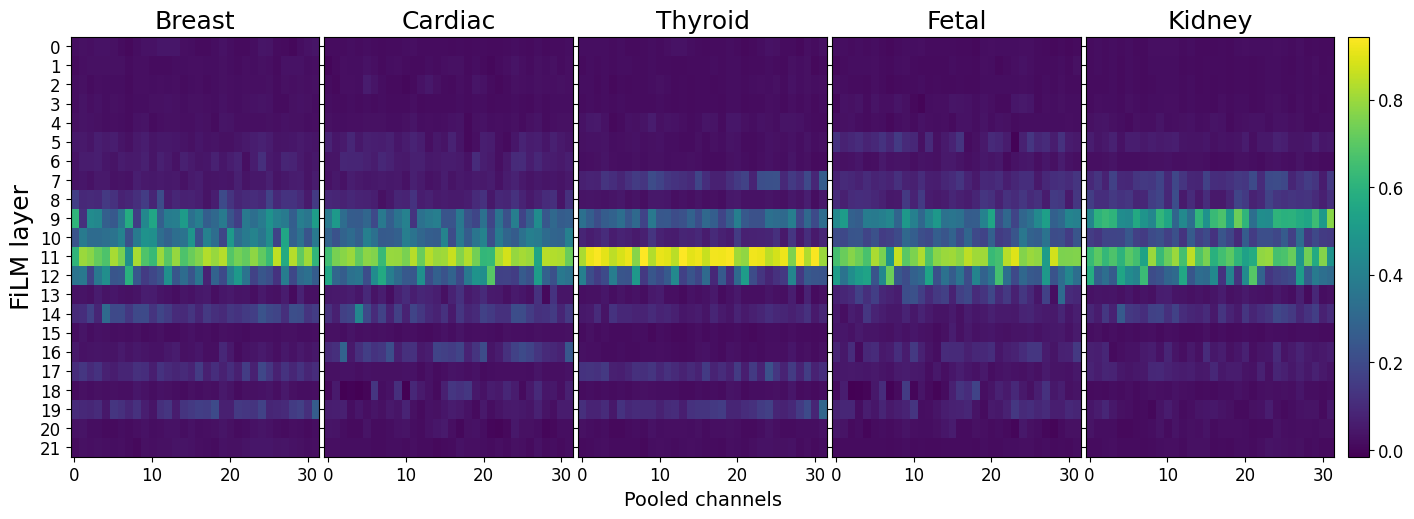

In [ ]:
# ── Mean γ per organ — test split, single row ─────────────────────────────────
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import class_to_organ_dict

POOL_K = 32
SKIP_ORGANS = {7}  # testicle excluded

unique_organs_vis = [
    int(x) for x in sorted(organ_ids_test_all.unique().tolist())
    if int(x) not in SKIP_ORGANS
]

gm_maps = []
for organ_id in unique_organs_vis:
    mask = organ_ids_test_all == organ_id
    gm = F.max_pool1d(gamma_test_all[mask], kernel_size=POOL_K).mean(dim=0)
    gm_maps.append(F.normalize(gm, p=2, dim=0).numpy())

vmin = min(g.min() for g in gm_maps)
vmax = max(g.max() for g in gm_maps)

n = len(unique_organs_vis)
fig, axes = plt.subplots(1, n, figsize=(3 * n + 0.8, 6), sharey=True)
axes = np.atleast_1d(axes)
# fig.suptitle('Mean γ per organ', fontsize=12)

for ax, organ_id, gm in zip(axes, unique_organs_vis, gm_maps):
    im = ax.imshow(gm, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    organ_str = class_to_organ_dict.get(organ_id, str(organ_id))
    if organ_str == 'breast_luminal': organ_str = 'breast'
    ax.set_title(organ_str.capitalize(), fontsize=18)
    if organ_id == 3:
        ax.set_xlabel('Pooled channels', fontsize=14)
    ax.set_yticks(range(gm.shape[0]))

    ax.tick_params(axis='y', labelsize=12)  # Change 14 to your desired size
    ax.tick_params(axis='x', labelsize=12)  # Change 14 to your desired size

axes[0].set_ylabel('FiLM layer', fontsize=18)
fig.subplots_adjust(left=0.055, right=0.94, top=0.86, bottom=0.16, wspace=0.02)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.01)
cbar.ax.tick_params(labelsize=12)  # Change 14 to your desired sizeplt.show()


In [15]:
unique_organs_vis

[1, 2, 3, 4, 5]